# Stanford Dogs 120종 분류 — 백본 비교 실험 (Local M2)

## 실험 구성
- **Phase 1**: 원본과 동일한 조건에서 백본만 교체하여 성능 비교
- **Phase 2**: Phase 1 최고 백본에 proper validation 적용

### 원본 기준 조건 (Phase 1 고정값)
| 항목 | 값 |
|------|----|
| Input size | 224×224 |
| Batch size | 32 |
| Epochs | 10 |
| LR | 0.0001 |
| Backbone | **frozen** (trainable=False) |
| Head | GlobalAveragePooling2D → Dense(120, softmax) |

## 공통 세팅 (항상 먼저 실행)

In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
SAVE_DIR = '/Users/sseung/Documents/study/pho/dog-ai-agent_mvp/ai-service/breed/experiments'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'결과 저장 경로: {SAVE_DIR}')

결과 저장 경로: /Users/sseung/Documents/study/pho/dog-ai-agent_mvp/ai-service/breed/experiments


In [5]:
INPUT_SHAPE = (224, 224, 3)
NUM_BREEDS  = 120
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 0.0001

(ds_train, ds_test), ds_info = tfds.load(
    'stanford_dogs',
    split=['train', 'test'],
    with_info=True,
    as_supervised=False,
)

# 백본별 전처리 기대값이 다름
# MobileNetV2: [0,1] 입력
# MobileNetV3Large, EfficientNetB0/B3: [0,255] 입력 (내부 전처리 레이어 있음)
NEEDS_NORM = {'mobilenetv2'}  # /255 필요한 백본

def make_preprocess(backbone_name):
    normalize = backbone_name in NEEDS_NORM
    def preprocess(sample):
        image = tf.cast(sample['image'], tf.float32)
        image = tf.image.resize(image, INPUT_SHAPE[:2])
        if normalize:
            image = image / 255.0
        label = tf.one_hot(sample['label'], NUM_BREEDS)
        return image, label
    return preprocess

def prepare(ds, backbone_name):
    ds = ds.map(make_preprocess(backbone_name), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print(f'Train: {ds_info.splits["train"].num_examples}장 / Test: {ds_info.splits["test"].num_examples}장')
print('전처리 함수 준비 완료 (백본별 별도 적용)')

Train: 12000장 / Test: 8580장
전처리 함수 준비 완료 (백본별 별도 적용)


2026-03-22 20:48:53.498007: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-22 20:48:53.498171: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-22 20:48:53.498182: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-22 20:48:53.498762: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-22 20:48:53.498775: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
def build_model(backbone_name):
    backbones = {
        'mobilenetv2':      tf.keras.applications.MobileNetV2,
        'mobilenetv3large': tf.keras.applications.MobileNetV3Large,
        'efficientnetb0':   tf.keras.applications.EfficientNetB0,
        'efficientnetb3':   tf.keras.applications.EfficientNetB3,
    }
    base = backbones[backbone_name](input_shape=INPUT_SHAPE, include_top=False, weights='imagenet')
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(NUM_BREEDS, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'top_k_categorical_accuracy']
    )
    return model


def run_phase1(backbone_name):
    print(f'\n{"="*60}')
    print(f'  Phase 1 [{backbone_name}]')
    print(f'{"="*60}')

    tf.keras.backend.clear_session()
    tf.random.set_seed(0)
    model = build_model(backbone_name)
    model.summary()

    # 백본별 전처리 적용
    train_b = prepare(ds_train, backbone_name)
    test_b  = prepare(ds_test,  backbone_name)

    t0 = time.time()
    history = model.fit(
        train_b,
        epochs=EPOCHS,
        validation_data=test_b,
        verbose=1
    )
    elapsed = time.time() - t0

    # 추론 시간 (단일 이미지, 50회 평균)
    sample_img = next(iter(test_b))[0][:1]
    _ = model.predict(sample_img, verbose=0)
    infer_list = []
    for _ in range(50):
        t = time.time()
        model.predict(sample_img, verbose=0)
        infer_list.append((time.time() - t) * 1000)
    infer_ms = np.mean(infer_list)

    # 모델 저장 및 크기 계산
    model_path = f'{SAVE_DIR}/{backbone_name}_phase1.keras'
    model.save(model_path)
    size_mb = round(os.path.getsize(model_path) / 1024 / 1024, 1)

    val_acc  = history.history['val_accuracy']
    val_top5 = history.history['val_top_k_categorical_accuracy']

    # CSV 저장
    result = {
        'backbone':       backbone_name,
        'val_acc_last':   round(val_acc[-1], 4),
        'val_acc_best':   round(max(val_acc), 4),
        'val_top5_best':  round(max(val_top5), 4),
        'train_time_min': round(elapsed / 60, 1),
        'infer_ms':       round(infer_ms, 2),
        'model_size_mb':  round(size_mb, 1),
    }
    pd.DataFrame([result]).to_csv(f'{SAVE_DIR}/phase1_{backbone_name}.csv', index=False)

    # 학습 곡선 PNG 저장
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, EPOCHS + 1)
    axes[0].plot(ep, history.history['accuracy'], label='train')
    axes[0].plot(ep, val_acc, label='val')
    axes[0].set_title(f'Accuracy [{backbone_name}]')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(ep, history.history['loss'], label='train')
    axes[1].plot(ep, history.history['val_loss'], label='val')
    axes[1].set_title(f'Loss [{backbone_name}]')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/phase1_{backbone_name}.png', dpi=150)
    plt.show()

    print(f'\n[{backbone_name}] 완료')
    print(f'  val_acc (best) : {result["val_acc_best"]}')
    print(f'  val_top5 (best): {result["val_top5_best"]}')
    print(f'  추론 시간       : {result["infer_ms"]}ms')
    print(f'  모델 크기       : {result["model_size_mb"]}MB')
    print(f'  저장 완료       : {SAVE_DIR}')
    return result


print('함수 정의 완료.')

함수 정의 완료.


---
## Phase 1 — MobileNetV2 (원본 기준)

In [12]:
result_mobilenetv2 = run_phase1('mobilenetv2')


  Phase 1 [mobilenetv2]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 153,720 (600.47 KB)

...

Epoch 1/10


2026-03-22 20:04:47.396082: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 204ms/step - accuracy: 0.2323 - loss: 3.6719 - top_k_categorical_accuracy: 0.5096 - val_accuracy: 0.4861 - val_loss: 2.6359 - val_top_k_categorical_accuracy: 0.8563
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 76s 198ms/step - accuracy: 0.6121 - loss: 2.0470 - top_k_categorical_accuracy: 0.9195 - val_accuracy: 0.6646 - val_loss: 1.6973 - val_top_k_categorical_accuracy: 0.9368
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 221ms/step - accuracy: 0.7253 - loss: 1.3853 - top_k_categorical_accuracy: 0.9596 - val_accuracy: 0.7136 - val_loss: 1.3034 - val_top_k_categorical_accuracy: 0.9523
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 198ms/step - accuracy: 0.7717 - loss: 1.0751 - top_k_categorical_accuracy: 0.9718 - val_accuracy: 0.7388 - val_loss: 1.1066 - val_top_k_categorical_accuracy: 0.9586
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - accuracy: 0.7986 - loss: 0.8990 - top_k_categorical_accuracy: 0.9787 - val_accuracy: 0.7552 - val_loss: 0.9921 - val_t

2026-03-22 20:17:39.573712: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/Users/sseung/Documents/study/pho/dog-ai-agent_mvp/ai-service/breed/experiments/mobilenetv2_phase1.

---
## Phase 1 — MobileNetV3Large


  Phase 1 [mobilenetv3large]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       115,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,111,672 (11.87 MB)

 Trainable params: 115,320 (450.47 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Epoch 1/10


2026-03-22 20:49:06.968778: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-22 20:49:06.972668: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.1428 - loss: 4.0215 - top_k_categorical_accuracy: 0.3418 - val_accuracy: 0.3346 - val_loss: 2.8927 - val_top_k_categorical_accuracy: 0.6928
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 229ms/step - accuracy: 0.5006 - loss: 2.2287 - top_k_categorical_accuracy: 0.8457 - val_accuracy: 0.5840 - val_loss: 1.8302 - val_top_k_categorical_accuracy: 0.9033
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 203ms/step - accuracy: 0.6756 - loss: 1.4854 - top_k_categorical_accuracy: 0.9426 - val_accuracy: 0.6817 - val_loss: 1.3771 - val_top_k_categorical_accuracy: 0.9392
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 226ms/step - accuracy: 0.7511 - loss: 1.1319 - top_k_categorical_accuracy: 0.9649 - val_accuracy: 0.7249 - val_loss: 1.1476 - val_top_k_categorical_accuracy: 0.9519
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 208ms/step - accuracy: 0.7884 - loss: 0.9313 - top_k_categorical_accuracy: 0.9743 - val_accuracy: 0.7449 - val_loss: 1.0128 - val_t

2026-03-22 21:02:29.271987: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


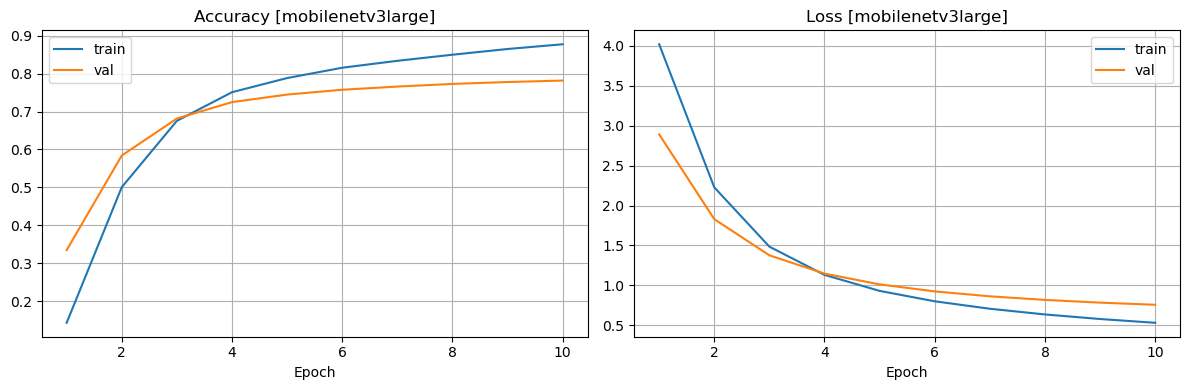


[mobilenetv3large] 완료
  val_acc (best) : 0.7818
  val_top5 (best): 0.9678
  추론 시간       : 41.97ms
  모델 크기       : 13.4MB
  저장 완료       : /Users/sseung/Documents/study/pho/dog-ai-agent_mvp/ai-service/breed/experiments


In [7]:
result_mobilenetv3large = run_phase1('mobilenetv3large')

---
## Phase 1 — EfficientNetB0


  Phase 1 [efficientnetb0]
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

...

2026-03-22 21:03:56.313230: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.1300 - loss: 4.3653 - top_k_categorical_accuracy: 0.3121

2026-03-22 21:05:16.550144: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


375/375 ━━━━━━━━━━━━━━━━━━━━ 138s 353ms/step - accuracy: 0.2856 - loss: 3.9102 - top_k_categorical_accuracy: 0.5686 - val_accuracy: 0.5893 - val_loss: 3.0396 - val_top_k_categorical_accuracy: 0.9207
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 285ms/step - accuracy: 0.6728 - loss: 2.4729 - top_k_categorical_accuracy: 0.9532 - val_accuracy: 0.7484 - val_loss: 1.9605 - val_top_k_categorical_accuracy: 0.9702
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 113s 299ms/step - accuracy: 0.7730 - loss: 1.6616 - top_k_categorical_accuracy: 0.9753 - val_accuracy: 0.7988 - val_loss: 1.3936 - val_top_k_categorical_accuracy: 0.9786
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 113s 298ms/step - accuracy: 0.8125 - loss: 1.2325 - top_k_categorical_accuracy: 0.9813 - val_accuracy: 0.8186 - val_loss: 1.0938 - val_top_k_categorical_accuracy: 0.9809
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 117s 311ms/step - accuracy: 0.8305 - loss: 0.9891 - top_k_categorical_accuracy: 0.9842 - val_accuracy: 0.8322 - val_loss: 0.9196 - 

2026-03-22 21:23:26.982642: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


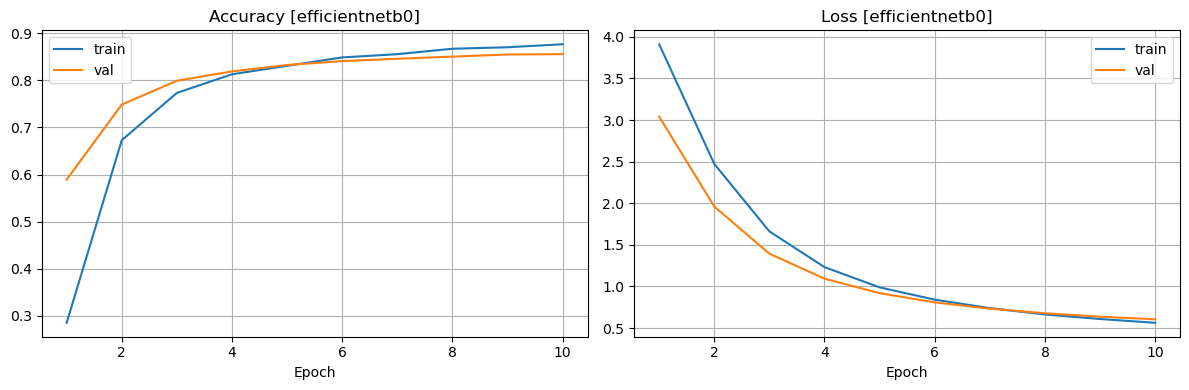


[efficientnetb0] 완료
  val_acc (best) : 0.8552
  val_top5 (best): 0.9867
  추론 시간       : 54.26ms
  모델 크기       : 18.0MB
  저장 완료       : /Users/sseung/Documents/study/pho/dog-ai-agent_mvp/ai-service/breed/experiments


In [8]:
result_efficientnetb0 = run_phase1('efficientnetb0')

---
## Phase 1 — EfficientNetB3

In [ ]:
result_efficientnetb3 = run_phase1('efficientnetb3')

---
## Phase 1 전체 결과 비교
> 위 4개 백본 모두 실행 후 아래 셀 실행

In [9]:
import glob

csv_files = sorted(glob.glob(f'{SAVE_DIR}/phase1_*.csv'))
df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df_all = df_all.sort_values('val_acc_best', ascending=False).reset_index(drop=True)
df_all.to_csv(f'{SAVE_DIR}/phase1_summary.csv', index=False)

print('=== Phase 1 전체 결과 ===')
print(df_all.to_string(index=False))

best_backbone = df_all.iloc[0]['backbone']
print(f'\n최고 백본: {best_backbone}')

=== Phase 1 전체 결과 ===
        backbone  val_acc_last  val_acc_best  val_top5_best  train_time_min  infer_ms  model_size_mb
  efficientnetb0        0.8552        0.8552         0.9867            19.4     54.26           18.0
mobilenetv3large        0.7818        0.7818         0.9678            13.4     41.97           13.4
     mobilenetv2        0.7790        0.7790         0.9672            13.1     40.11           10.9

최고 백본: efficientnetb0


---
## Phase 2 — 최고 백본에 proper validation 적용
> **`BEST_BACKBONE`을 Phase 1 결과 보고 직접 입력하세요.**

In [ ]:
BEST_BACKBONE  = 'efficientnetb0'
PHASE2_EPOCHS  = 30
VAL_PER_CLASS  = 20

# ── test에서 클래스당 20장을 val로 분리 (단일 패스, uint8로 메모리 절약) ──
class_counts = [0] * NUM_BREEDS
val_imgs, val_labels_list   = [], []
test_imgs, test_labels_list = [], []

for sample in ds_test:
    label = int(sample['label'])
    img = tf.cast(tf.image.resize(sample['image'], INPUT_SHAPE[:2]), tf.uint8).numpy()
    if class_counts[label] < VAL_PER_CLASS:
        val_imgs.append(img);  val_labels_list.append(label)
        class_counts[label] += 1
    else:
        test_imgs.append(img); test_labels_list.append(label)

val_imgs  = np.array(val_imgs,  dtype=np.uint8)
test_imgs = np.array(test_imgs, dtype=np.uint8)
val_labels_arr  = np.array(val_labels_list,  dtype=np.int32)
test_labels_arr = np.array(test_labels_list, dtype=np.int32)

print(f'Val : {len(val_labels_list)}장 ({VAL_PER_CLASS}장/종 × {NUM_BREEDS}종)')
print(f'Test: {len(test_labels_list)}장')

# ── uint8 배열 → tf.data (float32 변환은 배치 단위로) ──
normalize = BEST_BACKBONE in NEEDS_NORM

def img_label_to_tensor(img, lbl):
    img = tf.cast(img, tf.float32)
    if normalize:
        img = img / 255.0
    return img, tf.one_hot(lbl, NUM_BREEDS)

def make_split_ds(imgs, labels):
    return (tf.data.Dataset.from_tensor_slices((imgs, labels))
            .map(img_label_to_tensor, num_parallel_calls=tf.data.AUTOTUNE)
            .cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_b  = make_split_ds(val_imgs,  val_labels_arr)
test_b = make_split_ds(test_imgs, test_labels_arr)

# ── 모델 빌드 + 학습 ──
tf.keras.backend.clear_session()
tf.random.set_seed(0)
model_p2 = build_model(BEST_BACKBONE)

best_model_path = f'{SAVE_DIR}/{BEST_BACKBONE}_phase2_best.keras'
train_b = prepare(ds_train, BEST_BACKBONE)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

t0 = time.time()
history_p2 = model_p2.fit(
    train_b,
    epochs=PHASE2_EPOCHS,
    validation_data=val_b,
    callbacks=callbacks,
    verbose=1
)
elapsed_p2 = time.time() - t0
actual_epochs = len(history_p2.history['val_accuracy'])
print(f'Phase 2 완료 ({elapsed_p2/60:.1f}분) / 실제 에폭: {actual_epochs}')

In [ ]:
print('=== Phase 2 최종 평가 (분리된 test set) ===')
eval_res = model_p2.evaluate(test_b, verbose=1, return_dict=True)

p2_result = {
    'backbone':       BEST_BACKBONE,
    'phase':          'Phase2',
    'val_acc_best':   round(max(history_p2.history['val_accuracy']), 4),
    'val_top5_best':  round(max(history_p2.history['val_top_k_categorical_accuracy']), 4),
    'test_acc':       round(eval_res['accuracy'], 4),
    'test_top5':      round(eval_res['top_k_categorical_accuracy'], 4),
    'val_size':       len(val_labels_list),
    'test_size':      len(test_labels_list),
    'epochs_run':     actual_epochs,
    'train_time_min': round(elapsed_p2 / 60, 1),
}
pd.DataFrame([p2_result]).to_csv(f'{SAVE_DIR}/phase2_{BEST_BACKBONE}.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, actual_epochs + 1)
axes[0].plot(ep, history_p2.history['accuracy'], label='train')
axes[0].plot(ep, history_p2.history['val_accuracy'], label='val')
axes[0].set_title(f'Accuracy [{BEST_BACKBONE}] Phase 2')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(ep, history_p2.history['loss'], label='train')
axes[1].plot(ep, history_p2.history['val_loss'], label='val')
axes[1].set_title(f'Loss [{BEST_BACKBONE}] Phase 2')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/phase2_{BEST_BACKBONE}.png', dpi=150)
plt.show()

print(f'\n[결과]')
print(f'  val_acc (best) : {p2_result["val_acc_best"]}')
print(f'  test_acc       : {p2_result["test_acc"]}')
print(f'  test_top5      : {p2_result["test_top5"]}')
print(f'저장 완료: {SAVE_DIR}')

---
## Phase 2 — 이어서 학습 (EarlyStopping 미발동 시)

In [ ]:
# 저장된 best 모델 로드 후 이어서 학습
# EXTRA_EPOCHS: 추가할 에폭 수 (현재 30에서 얼마나 더 돌릴지)
EXTRA_EPOCHS = 20

model_p2 = tf.keras.models.load_model(best_model_path)
print(f'모델 로드 완료: {best_model_path}')

# callbacks 재사용 (best_model_path 동일 — 더 좋은 val_loss 나오면 덮어씀)
t0 = time.time()
history_p2_cont = model_p2.fit(
    train_b,
    epochs=EXTRA_EPOCHS,
    validation_data=val_b,
    callbacks=callbacks,
    verbose=1
)
elapsed_cont = time.time() - t0
actual_epochs_cont = len(history_p2_cont.history['val_accuracy'])
print(f'이어서 학습 완료 ({elapsed_cont/60:.1f}분) / 추가 에폭: {actual_epochs_cont}')

# 최종 평가
eval_res_cont = model_p2.evaluate(test_b, verbose=1, return_dict=True)

p2_cont_result = {
    'backbone':       BEST_BACKBONE,
    'phase':          'Phase2_cont',
    'val_acc_best':   round(max(history_p2_cont.history['val_accuracy']), 4),
    'val_top5_best':  round(max(history_p2_cont.history['val_top_k_categorical_accuracy']), 4),
    'test_acc':       round(eval_res_cont['accuracy'], 4),
    'test_top5':      round(eval_res_cont['top_k_categorical_accuracy'], 4),
    'epochs_run':     actual_epochs_cont,
    'train_time_min': round(elapsed_cont / 60, 1),
}
pd.DataFrame([p2_cont_result]).to_csv(f'{SAVE_DIR}/phase2_{BEST_BACKBONE}_cont.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, actual_epochs_cont + 1)
axes[0].plot(ep, history_p2_cont.history['accuracy'], label='train')
axes[0].plot(ep, history_p2_cont.history['val_accuracy'], label='val')
axes[0].set_title(f'Accuracy [{BEST_BACKBONE}] Phase 2 cont.')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(ep, history_p2_cont.history['loss'], label='train')
axes[1].plot(ep, history_p2_cont.history['val_loss'], label='val')
axes[1].set_title(f'Loss [{BEST_BACKBONE}] Phase 2 cont.')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/phase2_{BEST_BACKBONE}_cont.png', dpi=150)
plt.show()

print(f'\n[결과]')
print(f'  val_acc (best) : {p2_cont_result["val_acc_best"]}')
print(f'  test_acc       : {p2_cont_result["test_acc"]}')
print(f'  test_top5      : {p2_cont_result["test_top5"]}')
print(f'저장 완료: {SAVE_DIR}')